In [1]:
import torch
import matplotlib.pyplot as plt 
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader


In [111]:
class SVM(nn.Module):
    def __init__(self, num_classes):
        super(SVM, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 15),
            nn.ReLU(),
            nn.Linear(15, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()
        )
    def forward(self, data):
        return self.model(data) 
        

In [112]:
x = torch.randn(100)
y= torch.arange(100)
circ = 100 - y**2

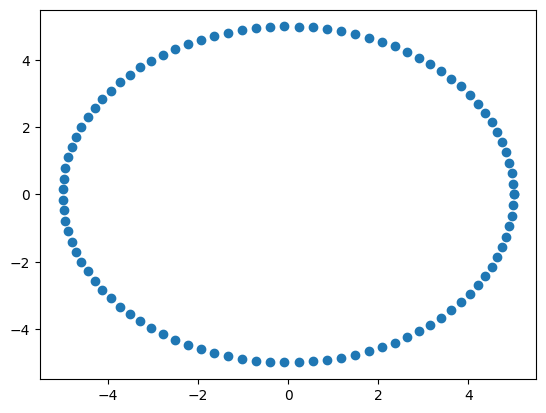

In [113]:
radius = 5
theta = np.linspace(0, 2 * np.pi, 100)  # 100 points around the circle
x_center, y_center = 0, 0  # Center of the circle

# Circle coordinates
x = x_center + radius * np.cos(theta) 
y = y_center + radius * np.sin(theta)
# plt.figure(figsize=(6, 6))
plt.scatter(x, y)  # Draw the circle

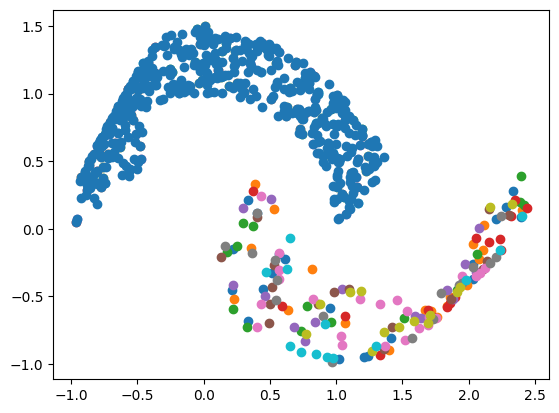

In [216]:
class TwoCirclesDataset(Dataset):
    def __init__(self, num_samples=1000, radius=1.0):
        self.num_samples = num_samples
        self.radius = radius

        # Generate random angles
        angles_circle1 =  np.pi * np.random.rand(num_samples // 2)
        angles_circle2 = -np.pi * np.random.rand(num_samples // 2)
        rnd = np.random.rand(num_samples//2)/2

        # Generate points for circle 1 (centered at (0, 0))
        self.circle1 = np.column_stack(( radius * np.cos(angles_circle1 + rnd),
                                         radius * np.sin(angles_circle1)) + rnd)


        rnd = np.random.rand(num_samples//2)/2
        # Generate points for circle 2 (centered at (2, 0))
        self.circle2 = np.column_stack(( (radius) * np.cos(angles_circle2) + rnd+1,
                                         (radius) * np.sin(angles_circle2) + rnd ))



        # Combine and create labels
        self.data = np.vstack((self.circle1, self.circle2))
        self.labels = np.array([0] * (num_samples // 2) + [1] * (num_samples // 2))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        return torch.tensor(sample, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Create dataset instance
dataset = TwoCirclesDataset(num_samples=1000)

# Create a DataLoader
plt.Figure(figsize=(10, 10))
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
data = next(iter(data_loader))
for i, data in enumerate(data_loader):
    plt.scatter(*zip(*data[0]))
    # print(data[0])
    if i == 9: break
# print(dataset.circle1)
plt.scatter(*zip(*dataset.circle1))

In [217]:
class classify(nn.Module):
    def __init__(self):
        pass
    def forward(self, data):
        if data.min < -1:
            return 1
        return 0

In [218]:
model = SVM(num_classes = 2)
optimizer = torch.optim.SGD(model.parameters(), momentum= 0.5, lr= 0.05) #using default parameters
loss = nn.BCELoss()

In [219]:
num_epochs = 10
def biniarize(val):
    if val < 0:
        return 0
    i

In [220]:
loss_list = []
for epoch in range(num_epochs):
    for i, data in enumerate(data_loader):
        optimizer.zero_grad()
        pts , label = data
        output = model(pts)
        # output.ceil_()
        print(output)
        ls = loss(output.view(-1).to(torch.float), label.to(torch.float))
        ls.backward()
        optimizer.step()
        # print(ls)
        loss_list.append(ls.detach())
    print(f"Epoch : {epoch}/{num_epochs}    Loss: {loss_list[epoch]}")
print(loss_list)


        

tensor([[0.4810],
        [0.4842],
        [0.4860],
        [0.5006],
        [0.4856],
        [0.4824],
        [0.4846],
        [0.5013],
        [0.5021],
        [0.4996],
        [0.4884],
        [0.4988],
        [0.4951],
        [0.4952],
        [0.4861],
        [0.5025],
        [0.5016],
        [0.4836],
        [0.4843],
        [0.4889],
        [0.4928],
        [0.4967],
        [0.4787],
        [0.4943],
        [0.4994],
        [0.4987],
        [0.4788],
        [0.5021],
        [0.4971],
        [0.4858],
        [0.5025],
        [0.4820]], grad_fn=<SigmoidBackward0>)
tensor([[0.4767],
        [0.4914],
        [0.4790],
        [0.4759],
        [0.4834],
        [0.4868],
        [0.4976],
        [0.4817],
        [0.4819],
        [0.4958],
        [0.4902],
        [0.4959],
        [0.4793],
        [0.4966],
        [0.4803],
        [0.4978],
        [0.4834],
        [0.4978],
        [0.4805],
        [0.4922],
        [0.4880],
        [0.4968],

In [221]:
test = next(iter(DataLoader(TwoCirclesDataset(100), batch_size= 32)))
op = model(test[0])
print(op)

tensor([[7.0169e-04],
        [6.7651e-04],
        [2.7751e-04],
        [1.2808e-02],
        [2.1237e-01],
        [1.5339e-03],
        [4.3188e-04],
        [4.2927e-02],
        [2.2810e-04],
        [1.2816e-03],
        [6.8311e-04],
        [6.9740e-04],
        [2.0750e-03],
        [1.7143e-04],
        [1.5880e-03],
        [3.9873e-03],
        [2.3122e-03],
        [4.7314e-02],
        [2.8900e-01],
        [3.8388e-04],
        [5.8628e-04],
        [1.8401e-04],
        [4.2114e-04],
        [9.0788e-03],
        [6.2124e-04],
        [1.5826e-03],
        [7.9884e-04],
        [5.0717e-03],
        [9.9540e-04],
        [3.2553e-04],
        [3.8482e-04],
        [7.2783e-04]], grad_fn=<SigmoidBackward0>)


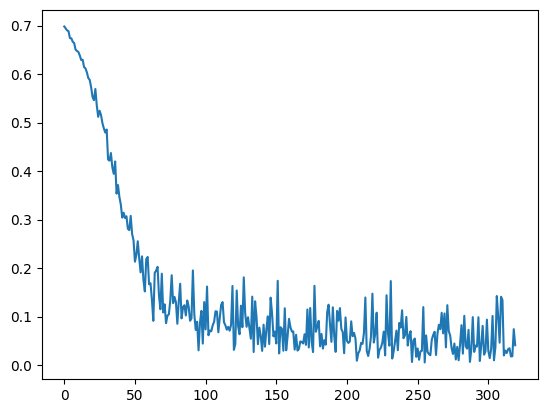

In [222]:
plt.plot(loss_list)

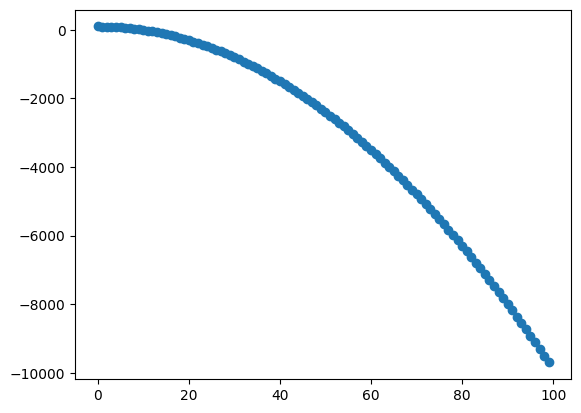

In [32]:
plt.scatter(torch.arange(100),circ)
# plt.scatter(torch.arange(1000), y)